In [1]:
import sys
import pywt
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy
from tqdm import tqdm

from radioimaging.deconvolution import fista
from radioimaging.deconvolution.fista import Filter2D
from radioimaging.util import util

wavelets=[pywt.Wavelet('db1'), pywt.Wavelet('db2'), pywt.Wavelet('db3'), pywt.Wavelet('db4'), pywt.Wavelet('db5'), \
         pywt.Wavelet('db6'), pywt.Wavelet('db7'), pywt.Wavelet('db8')]

cmap="turbo"

matplotlib.rcParams['figure.figsize'] = [10, 5]

For simplicity, both functions below assume that the subimages are square and fit exactly inside of the full image.
This can be updated later but for now it is not necessary

In [2]:
def split_image(img, dim):
    subimages = []

    div_x = img.shape[0] // dim
    div_y = img.shape[1] // dim

    for y in range(div_y):
        for x in range(div_x):
            subimages.append(img[dim*x:dim*(x+1), dim*y:dim*(y+1)])

    return subimages

def recon_image(subimages, shape):
    div_x = shape[0] // subimages[0].shape[0]
    div_y = shape[1] // subimages[0].shape[1]

    img = numpy.zeros(shape)
    dim = subimages[0].shape[0]
    
    for y in range(div_y):
        for x in range(div_x):
            img[dim*x:dim*(x+1), dim*y:dim*(y+1)] = subimages[x+y*div_x]

    return img

def cutout_psf(psf, shape):
    center = (psf.shape[0]//2+1, psf.shape[1]//2+1)
    hwx = shape[0]//2
    hwy = shape[1]//2
    
    return psf[center[0]-hwx:center[0]+hwx, center[1]-hwy:center[1]+hwy]
    

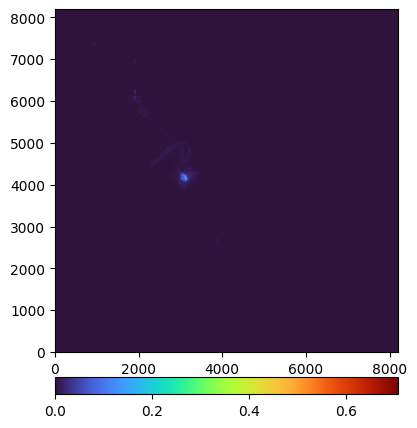

In [3]:
gt = util.fromfits("../data/MeerKAT1284Hz_cropped_and_zeroed_ext.fits")[10000-8192:10000, 10000-8192:10000]

util.plotNImages([gt], [""], cmap=cmap)

## Naive parallelization where cutouts are deconvolved in parallel as is

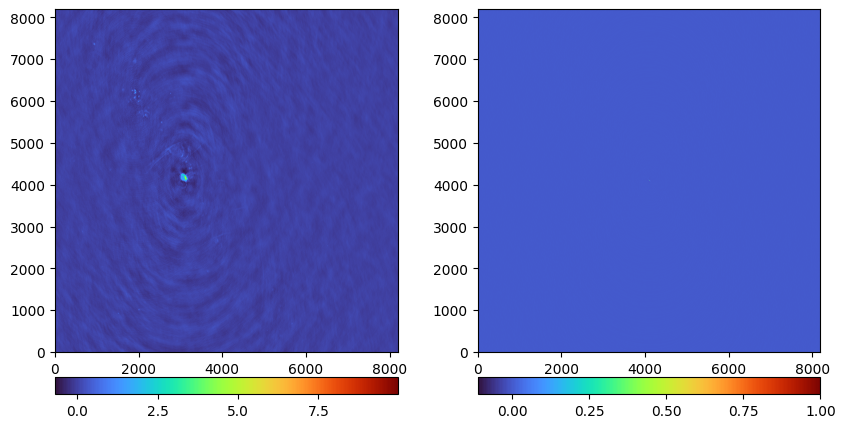

In [4]:
dirty_full = util.fromfits("../data8/Meerkat1284_dirty.fits")[10000-8192:10000, 10000-8192:10000]
psf_full = util.fromfits("../data8/Meerkat1284_psf.fits")[5000-4096:5000+4096,5000-4096:5000+4096] 
dim = 512

util.plotNImages([dirty_full, psf_full], ["", ""], cmap=cmap)

In [5]:
sub_images = split_image(dirty_full, dim)
sub_psf = Filter2D(cutout_psf(psf_full, (dim, dim)))

sub_deconvolveds = []

lmaxes = numpy.zeros(len(sub_images))
for sub_img in sub_images:
    lmaxes = fista.compute_lambda_max_ext(sub_img, sub_psf, wavelets)

lmax = numpy.max(lmaxes)

with tqdm(total=len(sub_images)) as pbar:
    for sub_img in sub_images:
        deconv = fista.fista(sub_psf, sub_img, 0.01, wavelets, 100, linear_conv=False, lambda_max=lmax)
        sub_deconvolveds.append(deconv)
        pbar.update(1)
    
gathered_deconvolved = recon_image(sub_deconvolveds, dirty_full.shape)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [42:33<00:00,  9.97s/it]


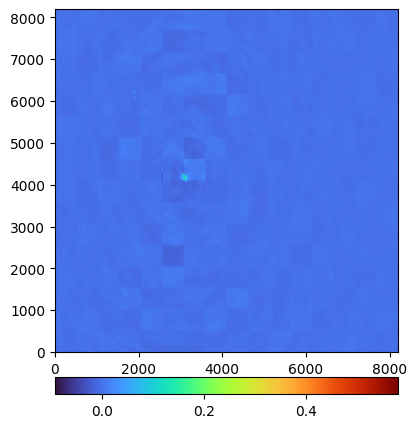

In [7]:
util.plotNImages([gathered_deconvolved], [""], cmap=cmap)
util.tofits(gathered_deconvolved, "../results/parallel_deconv/naive_parallel_deconv.fits")

## Split dataset (for now just do it directly on the images)

In [8]:
def split(img, ell, subsample_low=False, lowhw=0):
    low = numpy.zeros(img.shape, dtype=numpy.complex128)
    high = numpy.zeros(img.shape, dtype=numpy.complex128)

    fimg = numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(img)))

    ell2 = ell*ell

    middle = (img.shape[0]//2, img.shape[1]//2)
    
    for y in range(img.shape[1]):
        for x in range(img.shape[0]):
            fixed_x = x - middle[0]
            fixed_y = y - middle[0]
            d2 = fixed_y*fixed_y + fixed_x*fixed_x
            if d2 < ell2:
                low[x, y] = fimg[x, y]
            else:
                high[x, y] = fimg[x, y]

    if subsample_low:
        low = low[middle[0]-lowhw:middle[0]+lowhw, middle[1]-lowhw:middle[1]+lowhw]
        
    low = numpy.fft.ifftshift(numpy.fft.ifft2(numpy.fft.fftshift(low))).real
    high = numpy.fft.ifftshift(numpy.fft.ifft2(numpy.fft.fftshift(high))).real

    return low, high

def resample_low(img_low, target_shape):
    padding_x = ((target_shape[0] - img_low.shape[0])//2, int(numpy.ceil((target_shape[0] - img_low.shape[0])/2)))
    padding_y = ((target_shape[1] - img_low.shape[1])//2, int(numpy.ceil((target_shape[1] - img_low.shape[1])/2)))

    fimg_low = numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(img_low)))
    pfimg_low = numpy.pad(fimg_low, (padding_x, padding_y), 'constant')

    rimg_low = numpy.fft.ifftshift(numpy.fft.ifft2(numpy.fft.fftshift(pfimg_low))).real

    scaling = target_shape[0]*target_shape[1]/(img_low.shape[1]*img_low.shape[1])

    return rimg_low

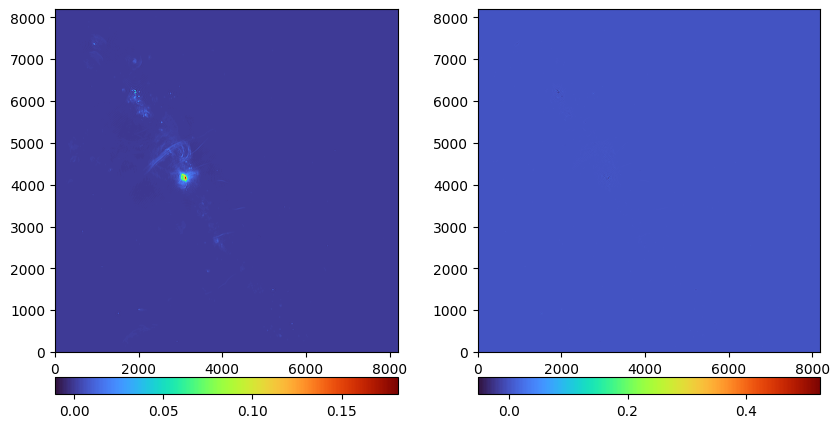

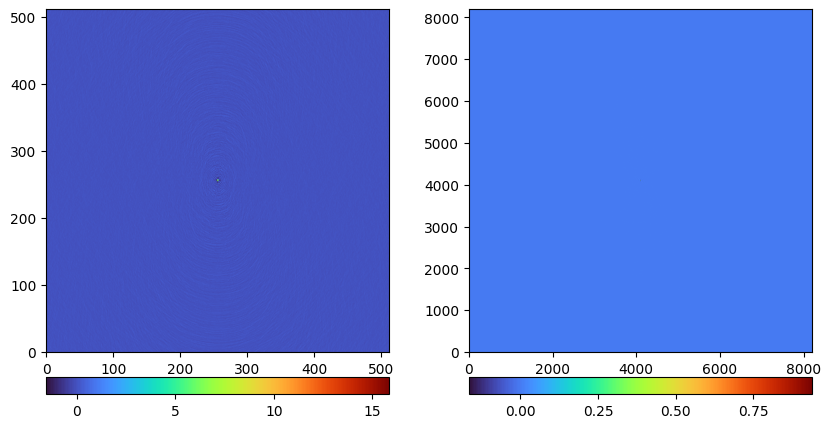

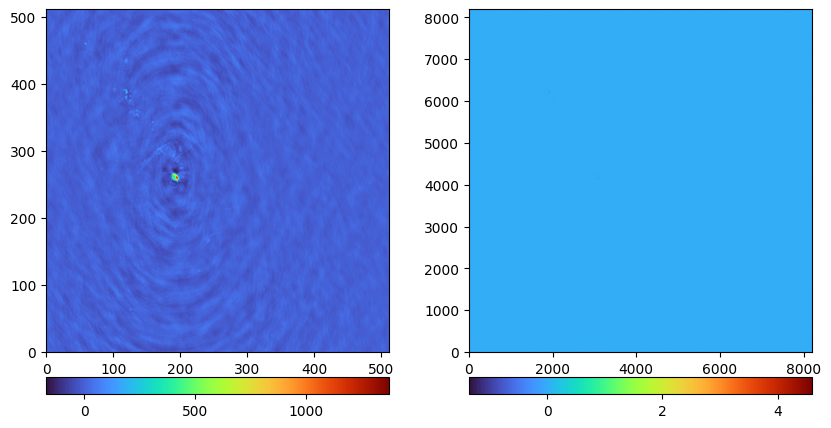

In [9]:
ell = 225
lowhw = 256

gt_low, gt_high = split(gt, ell, subsample_low=False)
psf_low, psf_high = split(psf_full, ell, subsample_low=True, lowhw=lowhw)
dirty_low, dirty_high = split(dirty_full, ell, subsample_low=True, lowhw=lowhw)

util.plotNImages([gt_low, gt_high], ["", ""], cmap=cmap)
util.plotNImages([psf_low, psf_high], ["", ""], cmap=cmap)
util.plotNImages([dirty_low, dirty_high], ["", ""], cmap=cmap)

util.tofits(gt_low, "../results/parallel_deconv/gt_low.fits")
util.tofits(gt_high, "../results/parallel_deconv/gt_high.fits")
util.tofits(psf_low, "../results/parallel_deconv/psf_low.fits")
util.tofits(psf_high, "../results/parallel_deconv/psf_high.fits")
util.tofits(dirty_low, "../results/parallel_deconv/dirty_low.fits")
util.tofits(dirty_high, "../results/parallel_deconv/dirty_high.fits")

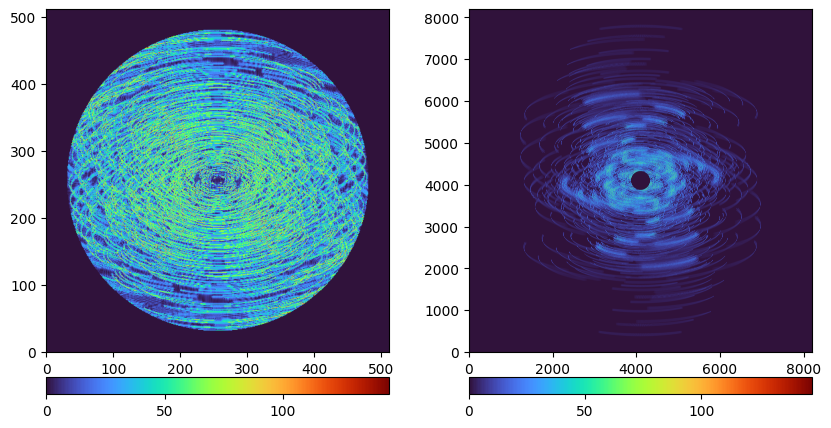

In [10]:
fpsflow = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(psf_low))))
fpsfhigh = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(psf_high))))
util.plotNImages([fpsflow, fpsfhigh], ["", ""], cmap="turbo")

In [11]:
sub_images_high = split_image(dirty_high, dim)
sub_psf_high = Filter2D(cutout_psf(psf_high, (dim, dim)))

sub_deconvolveds_high = []

lmaxes = numpy.zeros(len(sub_deconvolveds_high))
for sub_img_high in sub_images_high:
    lmaxes = fista.compute_lambda_max_ext(sub_img_high, sub_psf_high, wavelets)

lmax = numpy.max(lmaxes)

with tqdm(total=len(sub_images_high)) as pbar:
    for sub_img_high in sub_images_high:
        deconv = fista.fista(sub_psf_high, sub_img_high, 0.01, wavelets, 100, linear_conv=False, lambda_max=lmax)
        fdirty = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(sub_img_high))))
        fdeconv = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(deconv))))
        sub_deconvolveds_high.append(deconv)
        pbar.update(1)
    
gathered_deconvolved_high = recon_image(sub_deconvolveds_high, dirty_high.shape)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [43:34<00:00, 10.21s/it]


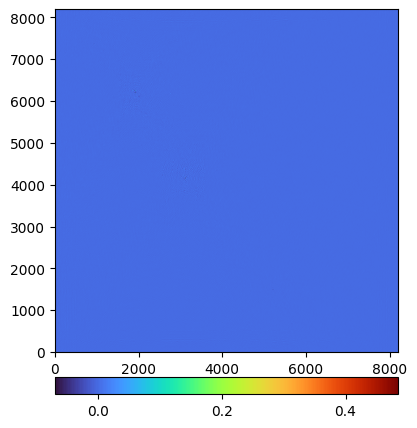

In [13]:
util.plotNImages([gathered_deconvolved_high], [""], cmap=cmap)
util.tofits(gathered_deconvolved_high, "../results/parallel_deconv/parallel_deconv_high.fits")

In [14]:
psf_low_filt = Filter2D(psf_low)

deconv_low = fista.fista(psf_low_filt, dirty_low, 0.01, wavelets, 100, linear_conv=False)

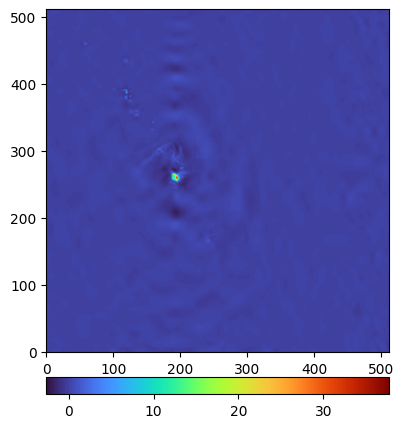

In [15]:
util.plotNImages([deconv_low], [""], cmap=cmap)
util.tofits(deconv_low, "../results/parallel_deconv/parallel_deconv_low.fits")

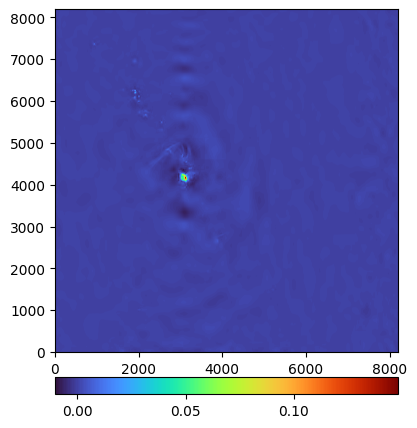

In [16]:
rdeconv_low = resample_low(deconv_low, dirty_full.shape)

util.plotNImages([rdeconv_low], [""], cmap=cmap)
util.tofits(rdeconv_low, "../results/parallel_deconv/parallel_deconv_low_resampled.fits")

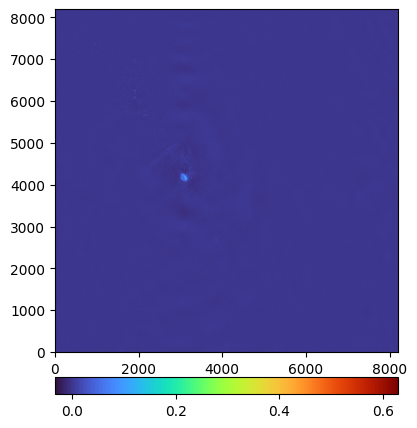

In [17]:
#should technically do one more run of fista to regularize together but just add for now
final_deconv = rdeconv_low + gathered_deconvolved_high

util.plotNImages([final_deconv], [""], cmap=cmap)
util.tofits(final_deconv, "../results/parallel_deconv/parallel_deconv_full.fits")

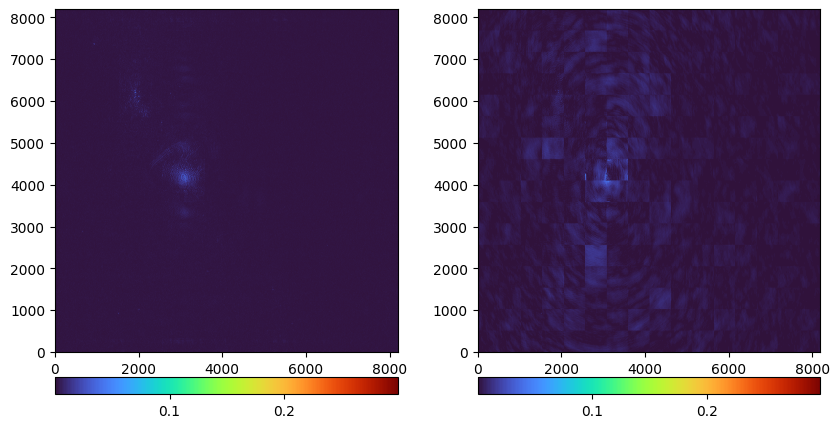

In [18]:
full_diff = numpy.abs(final_deconv - gt)
naive_diff = numpy.abs(gathered_deconvolved - gt)

util.plotNImages([full_diff, naive_diff], ["", ""], cmap=cmap, same_scale=True)
util.tofits(full_diff, "../results/parallel_deconv/parallel_deconv_full_diff.fits")
util.tofits(naive_diff, "../results/parallel_deconv/naive_deconv_full_diff.fits")

In [1]:
full_diff_conv = numpy.abs(dirty_full - fista.convolve2d(final_deconv, psf_full))
naive_diff_conv = numpy.abs(dirty_full - fista.convolve2d(gathered_deconvolved, psf_full))

util.plotNImages([full_diff_conv, naive_diff_conv], ["", ""], cmap=cmap, same_scale=True)
util.tofits(full_diff_conv, "../results/parallel_deconv/parallel_deconv_fullconv_diff.fits")
util.tofits(naive_diff_conv, "../results/parallel_deconv/naive_deconv_fullconv_diff.fits")

NameError: name 'numpy' is not defined